# Model Training

This notebook trains and compares classification models for Employee Attrition prediction using the processed dataset produced by
`02_data_preprocessing.ipynb`.

**Objectives**
- Load the processed train / test datasets
- Train multiple classification models
- Compare model performance using ROC AUC as the primary metric
- Cross-validate the best default model
- Hyperparameter-tune Logistic Regression
- Optimize the classification threshold using cross-validated probabilities
- Evaluate the final model on the held-out test set
- Save the final model, threshold, and training reports

# 1. Setup

In [39]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
REPORTS_DIR = "../reports"

X_TRAIN_CSV = os.path.join(DATA_DIR, "X_train.csv")
X_TEST_CSV = os.path.join(DATA_DIR, "X_test.csv")
Y_TRAIN_CSV = os.path.join(DATA_DIR, "y_train.csv")
Y_TEST_CSV = os.path.join(DATA_DIR, "y_test.csv")

EMPLOYEE_ATTRITION_MODEL_PKL = os.path.join(MODELS_DIR, "employee_attrition_model.pkl")
FINAL_MODEL_PKL = os.path.join(MODELS_DIR, "final_attrition_model.pkl")
BEST_THRESHOLD_PKL = os.path.join(MODELS_DIR, "best_threshold.pkl")

MODEL_COMPARISON_CSV = os.path.join(REPORTS_DIR, "model_comparison.csv")
TRAINING_SUMMARY_CSV = os.path.join(REPORTS_DIR, "training_summary.csv")

## 2. Load Processed Datasets

In [40]:
X_train = pd.read_csv(X_TRAIN_CSV)
X_test = pd.read_csv(X_TEST_CSV)

y_train = pd.read_csv(Y_TRAIN_CSV).squeeze()
y_test = pd.read_csv(Y_TEST_CSV).squeeze()

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape} | y_test  : {y_test.shape}")

X_train : (1176, 51) | y_train : (1176,)
X_test  : (294, 51) | y_test  : (294,)


## 3. Model Evaluation Function

In [41]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    }

    return results

## 4. Train and Compare Models

In [42]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [43]:
results = []

for name, model in models.items():
    metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
    metrics["Model"] = name
    results.append(metrics)

In [44]:
results_df = pd.DataFrame(results)
results_df = results_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]]
results_df = results_df.sort_values(by="ROC AUC", ascending=False)

results_df.to_csv(MODEL_COMPARISON_CSV, index=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356,0.811526
3,Gradient Boosting,0.860544,0.714286,0.212766,0.327869,0.805323
2,Random Forest,0.843537,0.555556,0.106383,0.178571,0.796236
1,Decision Tree,0.785714,0.318182,0.297872,0.307692,0.588207


Logistic Regression achieves the highest ROC AUC, closely followed by the Gradient Boosting. Because the classes are imbalanced, ROC AUC is a more reliable comparison metric than accuracy. The workflow proceeds by tuning the Logistic Regression and saving it as the final model.

## 5. Best Default Model (Logistic Regression)

In [45]:
best_model_name = results_df.iloc[0]["Model"]
print("Best default model:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

Best default model: Logistic Regression


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
predictions = best_model.predict(X_test)
cm = confusion_matrix(y_test, predictions)
cm

array([[237,  10],
       [ 31,  16]])

In [47]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



## 6. Cross-Validation (Logistic Regression)

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="roc_auc")

print("Fold scores:", scores.round(4))
print("Mean ROC AUC:", round(scores.mean(), 4))

Fold scores: [0.8203 0.8197 0.8604 0.8858 0.8098]
Mean ROC AUC: 0.8392


## 7. Hyperparameter Tuning

In [52]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC AUC:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}

Best Cross-Validation ROC AUC:
0.839


In [53]:
tuned_model = grid_search.best_estimator_

print(tuned_model)

LogisticRegression(C=1, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')


In [54]:
tuned_test_probabilities = tuned_model.predict_proba(X_test)[:, 1]

tuned_test_predictions = (tuned_test_probabilities >= 0.5).astype(int)

tuned_results = {
    "Accuracy": accuracy_score(y_test, tuned_test_predictions),
    "Precision": precision_score(y_test, tuned_test_predictions),
    "Recall": recall_score(y_test, tuned_test_predictions),
    "F1 Score": f1_score(y_test, tuned_test_predictions),
    "ROC AUC": roc_auc_score(y_test, tuned_test_probabilities)
}

pd.DataFrame(
    [tuned_results],
    index=["Tuned Logistic Regression"]
)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Tuned Logistic Regression,0.863946,0.62963,0.361702,0.459459,0.809114


In [55]:
from sklearn.model_selection import cross_val_predict
cv_probabilities = cross_val_predict(
    tuned_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [56]:
thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = (cv_probabilities >= threshold).astype(int)

    precision = precision_score(y_train, predictions, zero_division=0)
    recall = recall_score(y_train, predictions, zero_division=0)
    f1 = f1_score(y_train, predictions, zero_division=0)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    by="F1 Score",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1 Score
25,0.35,0.621622,0.605263,0.613333
24,0.34,0.609375,0.615789,0.612565
28,0.38,0.647059,0.578947,0.611111
26,0.36,0.627778,0.594737,0.610811
23,0.33,0.592040,0.626316,0.608696
29,0.39,0.654545,0.568421,0.608451
32,0.42,0.714286,0.526316,0.606061
27,0.37,0.625000,0.578947,0.601093
31,0.41,0.687075,0.531579,0.599407
22,0.32,0.572115,0.626316,0.597990


In [57]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold = float(best_threshold_row["Threshold"])

print("Best Threshold:", round(best_threshold, 2))
print("Precision:", round(best_threshold_row["Precision"], 4))
print("Recall:", round(best_threshold_row["Recall"], 4))
print("F1 Score:", round(best_threshold_row["F1 Score"], 4))

Best Threshold: 0.35
Precision: 0.6216
Recall: 0.6053
F1 Score: 0.6133


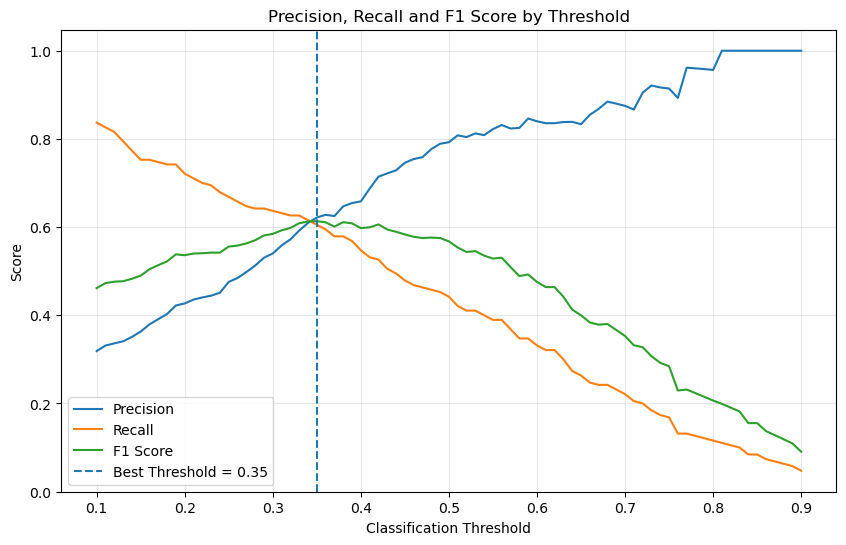

In [58]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score by Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [59]:
joblib.dump(best_threshold, BEST_THRESHOLD_PKL)

print(
    "Threshold saved:",
    os.path.exists(BEST_THRESHOLD_PKL)
)

Threshold saved: True


In [60]:
final_model = grid_search.best_estimator_

final_model.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [61]:
test_probabilities = final_model.predict_proba(X_test)[:, 1]

In [62]:
final_predictions = (
    test_probabilities >= best_threshold
).astype(int)

In [63]:
print("Final Model Performance")
print("=" * 50)

print(
    "Accuracy :",
    round(accuracy_score(y_test, final_predictions), 4)
)

print(
    "Precision:",
    round(precision_score(y_test, final_predictions), 4)
)

print(
    "Recall   :",
    round(recall_score(y_test, final_predictions), 4)
)

print(
    "F1 Score :",
    round(f1_score(y_test, final_predictions), 4)
)

print(
    "ROC AUC  :",
    round(roc_auc_score(y_test, test_probabilities), 4)
)

Final Model Performance
Accuracy : 0.8503
Precision: 0.5385
Recall   : 0.4468
F1 Score : 0.4884
ROC AUC  : 0.8091


In [64]:
print("\nClassification Report")
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["No Attrition", "Attrition"]
    )
)


Classification Report
              precision    recall  f1-score   support

No Attrition       0.90      0.93      0.91       247
   Attrition       0.54      0.45      0.49        47

    accuracy                           0.85       294
   macro avg       0.72      0.69      0.70       294
weighted avg       0.84      0.85      0.84       294



In [65]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, final_predictions))


Confusion Matrix
[[229  18]
 [ 26  21]]


In [66]:
joblib.dump(best_model, FINAL_MODEL_PKL)

['../models\\final_attrition_model.pkl']

In [67]:
joblib.dump(final_model, FINAL_MODEL_PKL)

print("Final model saved:", os.path.exists(FINAL_MODEL_PKL))

Final model saved: True


In [68]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC AUC:", grid_search.best_score_)

Best Parameters: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC AUC: 0.8390000728632842


In [69]:
from sklearn.model_selection import cross_val_predict

cv_probabilities = cross_val_predict(
    tuned_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Generated CV probabilities:", len(cv_probabilities))

Generated CV probabilities: 1176


In [70]:
thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = (cv_probabilities >= threshold).astype(int)

    precision = precision_score(
        y_train,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    by="F1 Score",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1 Score
25,0.35,0.621622,0.605263,0.613333
24,0.34,0.609375,0.615789,0.612565
28,0.38,0.647059,0.578947,0.611111
26,0.36,0.627778,0.594737,0.610811
23,0.33,0.592040,0.626316,0.608696
29,0.39,0.654545,0.568421,0.608451
32,0.42,0.714286,0.526316,0.606061
27,0.37,0.625000,0.578947,0.601093
31,0.41,0.687075,0.531579,0.599407
22,0.32,0.572115,0.626316,0.597990


In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Best threshold selected from CV predictions
BEST_THRESHOLD = 0.35

# Predict probabilities on the untouched test set
test_probabilities = tuned_model.predict_proba(X_test)[:, 1]

# Apply optimized threshold
test_predictions = (test_probabilities >= BEST_THRESHOLD).astype(int)

# Evaluate
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions, zero_division=0)
test_recall = recall_score(y_test, test_predictions, zero_division=0)
test_f1 = f1_score(y_test, test_predictions, zero_division=0)
test_roc_auc = roc_auc_score(y_test, test_probabilities)

print("Final Test Set Results")
print("=" * 40)
print(f"Threshold: {BEST_THRESHOLD}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"ROC AUC:   {test_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_predictions,
    target_names=["No Attrition", "Attrition"],
    zero_division=0
))

Final Test Set Results
Threshold: 0.35
Accuracy:  0.8503
Precision: 0.5385
Recall:    0.4468
F1 Score:  0.4884
ROC AUC:   0.8091

Confusion Matrix:
[[229  18]
 [ 26  21]]

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.90      0.93      0.91       247
   Attrition       0.54      0.45      0.49        47

    accuracy                           0.85       294
   macro avg       0.72      0.69      0.70       294
weighted avg       0.84      0.85      0.84       294



In [72]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save final tuned model
joblib.dump(
    tuned_model,
    "../models/final_attrition_model.pkl"
)

# Save decision threshold
joblib.dump(
    BEST_THRESHOLD,
    "../models/best_threshold.pkl"
)

print("Model and threshold saved successfully.")

print("\nModel:")
print(tuned_model)

print(f"\nBest Threshold: {BEST_THRESHOLD}")

Model and threshold saved successfully.

Model:
LogisticRegression(C=1, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

Best Threshold: 0.35


Logistic Regression achieved the strongest baseline ROC-AUC (0.8115) among the evaluated models. Hyperparameter tuning selected L1-regularized Logistic Regression (C=1, solver='liblinear'). Five-fold cross-validation produced a mean ROC-AUC of approximately 0.839. A decision threshold of 0.35 was subsequently selected using cross-validation predictions to improve the balance between precision and recall for the minority Attrition class. On the untouched test set, the final model achieved 0.809 ROC-AUC, 0.448 recall, and 0.488 F1-score for Attrition.